PHASE 1 — Import Libraries + Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

# Load dataset
df = pd.read_csv("./Dataset/airline_Delay_Dataset.csv") 
df.head()


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


BLOCK 2 — Basic Data Exploration & Cleaning

In [4]:
# Check shape of dataset
print("Shape:", df.shape)

# Check basic info
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Preview numerical summary
df.describe()


Shape: (171223, 21)

Data Types:
year                     int64
month                    int64
carrier                 object
carrier_name            object
airport                 object
airport_name            object
arr_flights            float64
arr_del15              float64
carrier_ct             float64
weather_ct             float64
nas_ct                 float64
security_ct            float64
late_aircraft_ct       float64
arr_cancelled          float64
arr_diverted           float64
arr_delay              float64
carrier_delay          float64
weather_delay          float64
nas_delay              float64
security_delay         float64
late_aircraft_delay    float64
dtype: object

Missing Values:
year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_c

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,171223.000000,171223.000000,171223.000000,171223.000000,171223.000000,171223.000000,171223.000000,171223.000000,171223.000000,171223.000000,171223.00000,171223.000000,171223.000000,171223.000000,171223.000000,171223.000000,171223.000000
mean,2018.549739,6.495284,362.946427,66.434387,20.821272,2.253015,19.404125,0.157283,23.798736,7.527686,0.86430,4244.513617,1438.889034,222.827365,921.743218,7.391478,1653.658299
std,2.891314,3.441753,993.408638,179.540694,50.339895,7.318176,61.708181,0.717809,72.431750,43.676378,3.77497,12625.199210,4217.885488,821.537321,3425.391326,41.803971,5224.663092
min,2013.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,3.000000,50.000000,6.000000,2.170000,0.000000,1.000000,0.000000,1.240000,0.000000,0.00000,336.000000,111.000000,0.000000,35.000000,0.000000,66.000000
50%,2019.000000,7.000000,101.000000,17.000000,6.410000,0.400000,3.930000,0.000000,5.000000,1.000000,0.00000,1020.000000,375.000000,18.000000,147.000000,0.000000,321.000000
75%,2021.000000,9.000000,250.000000,47.000000,17.300000,1.860000,11.730000,0.000000,15.280000,4.000000,1.00000,2888.500000,1110.000000,146.000000,478.000000,0.000000,1072.000000
max,2023.000000,12.000000,21977.000000,4176.000000,1293.910000,266.420000,1884.420000,58.690000,2069.070000,4951.000000,197.00000,438783.000000,196944.000000,31960.000000,112018.000000,3760.000000,227959.000000


BLOCK 3 — Create Helpful Derived Metrics for Analytics

In [5]:
# Create delay ratio (delayed flights / total flights)
df["delay_ratio"] = df["arr_del15"] / df["arr_flights"]

# Replace infinite values (if any)
df["delay_ratio"] = df["delay_ratio"].replace([np.inf, -np.inf], np.nan).fillna(0)

# Quick check
df[["arr_flights", "arr_del15", "delay_ratio"]].head()


,arr_flights,arr_del15,delay_ratio
0,89.0,13.0,0.146067
1,62.0,10.0,0.161290
2,62.0,10.0,0.161290
3,66.0,12.0,0.181818
4,92.0,22.0,0.239130


BLOCK 4 — Year-wise Delay Trends (Important Chart)

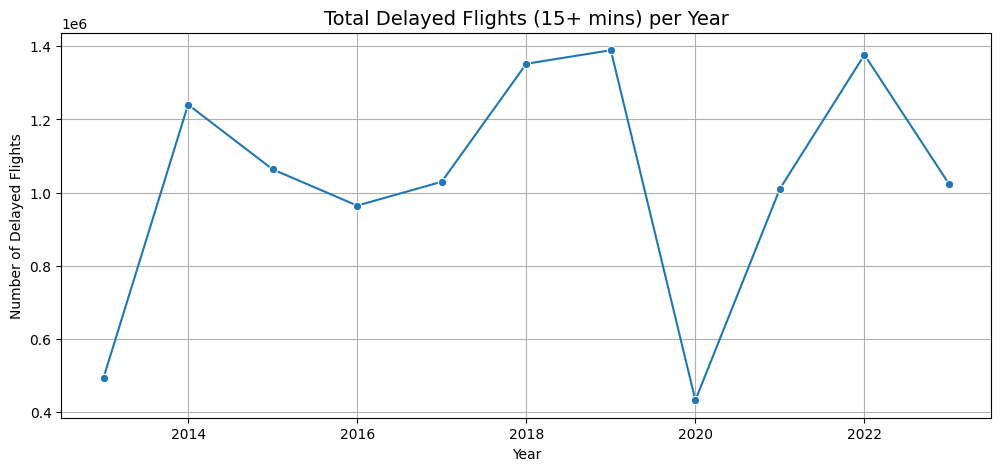

In [6]:
plt.figure(figsize=(12,5))
yearly = df.groupby("year")["arr_del15"].sum()

sns.lineplot(x=yearly.index, y=yearly.values, marker="o")
plt.title("Total Delayed Flights (15+ mins) per Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Number of Delayed Flights")
plt.grid(True)
plt.show()


BLOCK 5 — Month-wise Delay Patterns (Seasonality)

C:\Users\Gaian Solutions\AppData\Local\Temp\ipykernel_4288\3284082336.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly.index, y=monthly.values, palette="viridis")


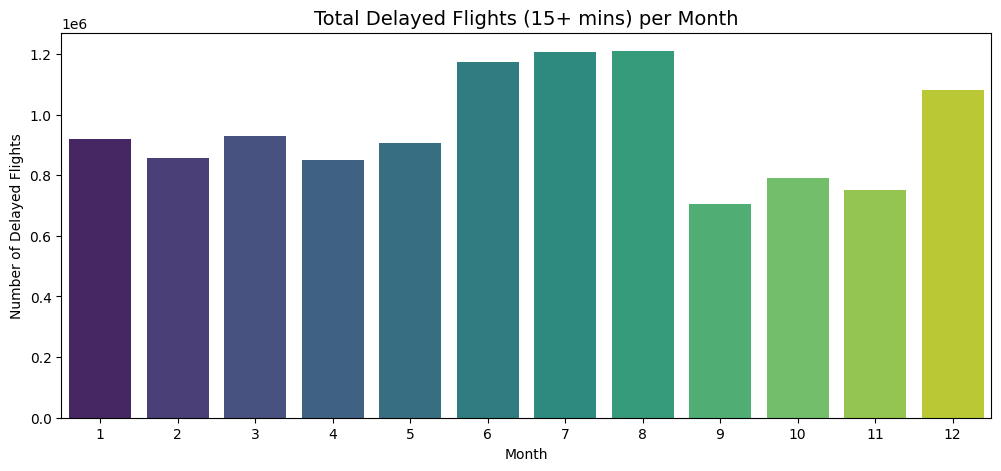

In [7]:
plt.figure(figsize=(12,5))
monthly = df.groupby("month")["arr_del15"].sum()

sns.barplot(x=monthly.index, y=monthly.values, palette="viridis")
plt.title("Total Delayed Flights (15+ mins) per Month", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Number of Delayed Flights")
plt.show()


BLOCK 6 — Top 15 Most Delayed Airports

C:\Users\Gaian Solutions\AppData\Local\Temp\ipykernel_4288\1822561931.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


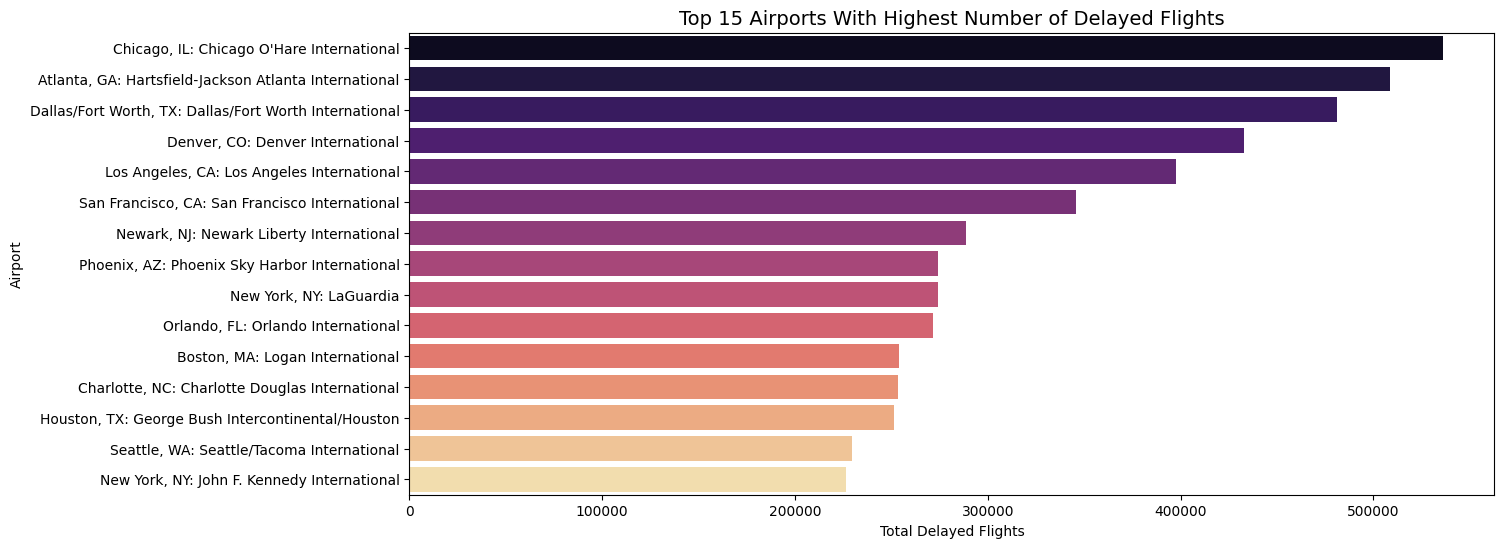

In [8]:
plt.figure(figsize=(14,6))

top_airports = (
    df.groupby("airport_name")["arr_del15"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

sns.barplot(
    y=top_airports.index,
    x=top_airports.values,
    palette="magma"
)

plt.title("Top 15 Airports With Highest Number of Delayed Flights", fontsize=14)
plt.xlabel("Total Delayed Flights")
plt.ylabel("Airport")
plt.show()


BLOCK 7 — Delay Causes Comparison (Carrier vs Weather vs NAS vs Late Aircraft)

C:\Users\Gaian Solutions\AppData\Local\Temp\ipykernel_4288\2056475729.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(cause_totals.keys()),


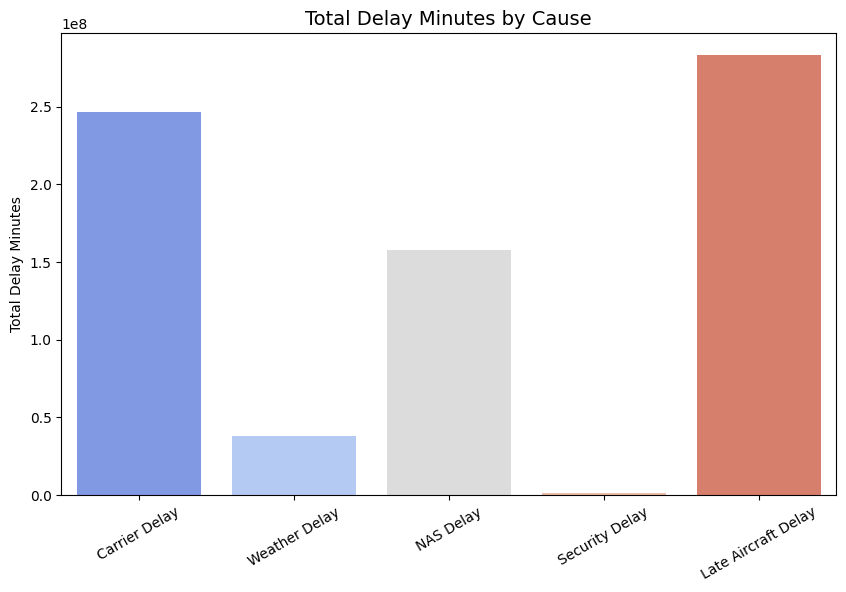

In [9]:
plt.figure(figsize=(10,6))

cause_totals = {
    "Carrier Delay": df["carrier_delay"].sum(),
    "Weather Delay": df["weather_delay"].sum(),
    "NAS Delay": df["nas_delay"].sum(),
    "Security Delay": df["security_delay"].sum(),
    "Late Aircraft Delay": df["late_aircraft_delay"].sum()
}

sns.barplot(x=list(cause_totals.keys()),
            y=list(cause_totals.values()),
            palette="coolwarm")

plt.title("Total Delay Minutes by Cause", fontsize=14)
plt.ylabel("Total Delay Minutes")
plt.xticks(rotation=30)
plt.show()


BLOCK 8 — Correlation Heatmap (Very Important for ML)

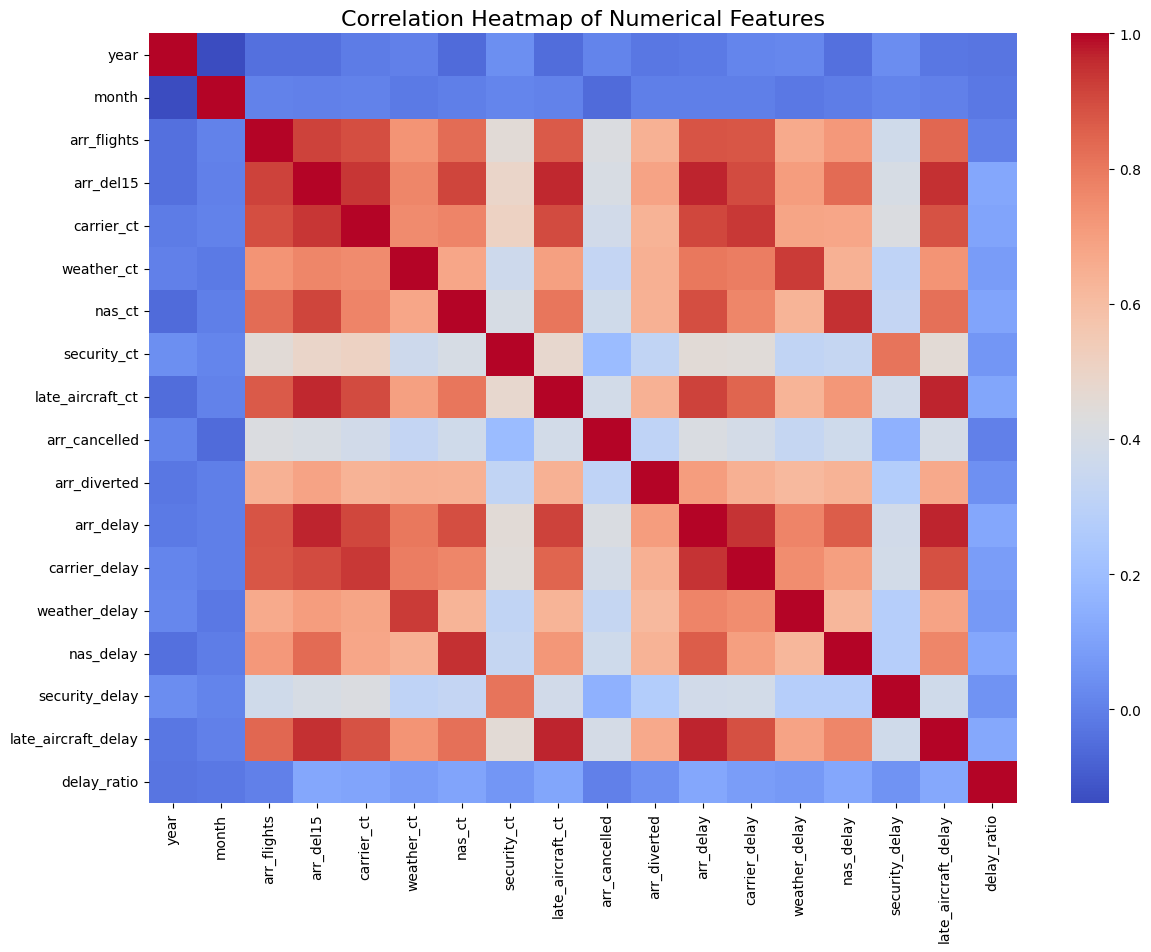

In [10]:
plt.figure(figsize=(14,10))

# Select only numerical columns
numeric_df = df.select_dtypes(include=[np.number])

corr = numeric_df.corr()

sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.show()


BLOCK 9 — Create Target Variable (delay/no delay)

In [11]:
# Create delay ratio
df["delay_ratio"] = df["arr_del15"] / df["arr_flights"]

# Compute threshold (mean delay ratio)
threshold = df["delay_ratio"].mean()

# Create target label
df["delay_label"] = (df["delay_ratio"] > threshold).astype(int)

df["delay_label"].value_counts()


delay_label
0    94257
1    76966
Name: count, dtype: int64

BLOCK 10 — Encode Categorical Features (Carrier + Airport)

In [12]:
from sklearn.preprocessing import LabelEncoder

# Create encoders
le_carrier = LabelEncoder()
le_airport = LabelEncoder()

# Fit + transform
df["carrier_encoded"] = le_carrier.fit_transform(df["carrier_name"])
df["airport_encoded"] = le_airport.fit_transform(df["airport_name"])

# Save encoders for later prediction from HTML form
import joblib
joblib.dump(le_carrier, "carrier_encoder.pkl")
joblib.dump(le_airport, "airport_encoder.pkl")

df[["carrier_name", "carrier_encoded", "airport_name", "airport_encoded"]].head()


,carrier_name,carrier_encoded,airport_name,airport_encoded
0,Endeavor Air Inc.,6,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",10
1,Endeavor Air Inc.,6,"Albany, GA: Southwest Georgia Regional",6
2,Endeavor Air Inc.,6,"Alexandria, LA: Alexandria International",9
3,Endeavor Air Inc.,6,"Augusta, GA: Augusta Regional at Bush Field",21
4,Endeavor Air Inc.,6,"Albany, NY: Albany International",7


BLOCK 11 — Select Features for the ML Model

In [13]:
# Feature columns
features = [
    "year", "month",
    "carrier_encoded", "airport_encoded",
    "arr_flights", "carrier_ct", "weather_ct",
    "nas_ct", "security_ct", "late_aircraft_ct"
]

X = df[features]
y = df["delay_label"]

X.head()
# Train-test split

,year,month,carrier_encoded,airport_encoded,arr_flights,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct
0,2023,8,6,10,89.0,2.25,1.60,3.16,0.0,5.99
1,2023,8,6,6,62.0,1.97,0.04,0.57,0.0,7.42
2,2023,8,6,9,62.0,2.73,1.18,1.80,0.0,4.28
3,2023,8,6,21,66.0,3.69,2.27,4.47,0.0,1.57
4,2023,8,6,7,92.0,7.76,0.00,2.96,0.0,11.28


BLOCK 12 — Train-Test Split + Train Random Forest Model

This will:

✔ Split data
✔ Train the Random Forest classifier
✔ Predict
✔ Show accuracy

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the model
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9637903343553803

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97     18901
           1       0.95      0.97      0.96     15344

    accuracy                           0.96     34245
   macro avg       0.96      0.96      0.96     34245
weighted avg       0.96      0.96      0.96     34245



BLOCK 13 — Save the ML Model (.pkl file)

In [17]:
import joblib

# Save model
joblib.dump(model, "Model/flight_delay_model.pkl")

print("Model saved successfully!")


Model saved successfully!


BLOCK 14 — Create a Prediction Function (For Flask Use)

In [18]:
def predict_delay(year, month, carrier_name, airport_name,
                  arr_flights, carrier_ct, weather_ct, nas_ct, security_ct, late_aircraft_ct):

    # Load encoders
    le_carrier = joblib.load("Model/carrier_encoder.pkl")
    le_airport = joblib.load("Model/airport_encoder.pkl")
    model = joblib.load("Model/flight_delay_model.pkl")

    # Encode categorical inputs
    carrier_encoded = le_carrier.transform([carrier_name])[0]
    airport_encoded = le_airport.transform([airport_name])[0]

    # Build input array
    input_data = np.array([[year, month, carrier_encoded, airport_encoded,
                            arr_flights, carrier_ct, weather_ct,
                            nas_ct, security_ct, late_aircraft_ct]])

    # Predict
    prediction = model.predict(input_data)[0]

    return "Delay Expected" if prediction == 1 else "No Delay Expected"


# ---- Test the function with one row from dataset ----
sample = df.iloc[0]

print(
    predict_delay(
        sample["year"], sample["month"],
        sample["carrier_name"], sample["airport_name"],
        sample["arr_flights"], sample["carrier_ct"], sample["weather_ct"],
        sample["nas_ct"], sample["security_ct"], sample["late_aircraft_ct"]
    )
)


No Delay Expected


d:\root\github\Airport Flight Delay Analytics and Prediction\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


BLOCK A — Updated Prediction Function (use in Flask)

In [23]:
def predict_delay_new(year, month, carrier_name, airport_name):

    import joblib
    import numpy as np

    # Load encoders
    le_carrier = joblib.load("Model/carrier_encoder.pkl")
    le_airport = joblib.load("Model/airport_encoder.pkl")
    model = joblib.load("Model/flight_delay_model.pkl")

    # Filter historical data
    filtered = df[
        (df['carrier_name'] == carrier_name) &
        (df['airport_name'] == airport_name) &
        (df['month'] == month)
    ]

    # If data exists, use historical averages
    if len(filtered) > 0:
        arr_flights = filtered["arr_flights"].mean()
        carrier_ct = filtered["carrier_ct"].mean()
        weather_ct = filtered["weather_ct"].mean()
        nas_ct = filtered["nas_ct"].mean()
        security_ct = filtered["security_ct"].mean()
        late_aircraft_ct = filtered["late_aircraft_ct"].mean()
    else:
        # fallback: global averages by airport and carrier
        fallback = df[
            (df['carrier_name'] == carrier_name) &
            (df['airport_name'] == airport_name)
        ]

        if len(fallback) == 0:
            # total fallback: global averages
            arr_flights = df["arr_flights"].mean()
            carrier_ct = df["carrier_ct"].mean()
            weather_ct = df["weather_ct"].mean()
            nas_ct = df["nas_ct"].mean()
            security_ct = df["security_ct"].mean()
            late_aircraft_ct = df["late_aircraft_ct"].mean()
        else:
            arr_flights = fallback["arr_flights"].mean()
            carrier_ct = fallback["carrier_ct"].mean()
            weather_ct = fallback["weather_ct"].mean()
            nas_ct = fallback["nas_ct"].mean()
            security_ct = fallback["security_ct"].mean()
            late_aircraft_ct = fallback["late_aircraft_ct"].mean()

    # Encode categorical features
    carrier_encoded = le_carrier.transform([carrier_name])[0]
    airport_encoded = le_airport.transform([airport_name])[0]

    # Prepare input row
    input_data = np.array([[
        year, month, carrier_encoded, airport_encoded,
        arr_flights, carrier_ct, weather_ct, nas_ct,
        security_ct, late_aircraft_ct
    ]])

    # Predict
    prediction = model.predict(input_data)[0]
    return "Delay Expected" if prediction == 1 else "No Delay Expected"


# Example test
print(predict_delay_new(2027, 2, "Delta Air Lines Inc.", "Detroit, MI: Detroit Metro Wayne County"))


No Delay Expected


d:\root\github\Airport Flight Delay Analytics and Prediction\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
